<a href="https://colab.research.google.com/github/Silva015/tcc-2026/blob/main/Distancia_Entrada_MLSD_ResNet%2BKAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Distância de Disparo (MLSD) com ResNet152 + KAN
Este experimento adapta a rede KAN híbrida para classificar a distância de disparo (Medical-Legal Shooting Distance - MLSD) apenas em ferimentos de ENTRADA. As classes são:
0: Encostado (Contact)
1: Curta distância (Close range)
2: À distância (Distant)

In [1]:
# Instalação da implementação eficiente da rede KAN
!pip install git+https://github.com/Blealtan/efficient-kan -q

# Clonagem dos repositórios contendo os dados e códigos base
!git clone https://gitlab.com/lisa-unb/leguwoi.git -q
!git clone https://github.com/pedrogarciafreitas/FDCPUnBGunshotDB.git -q

import os
from glob import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models
from efficient_kan import KAN
import torch.optim as optim
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import random
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)
from sklearn.preprocessing import label_binarize


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executando no dispositivo: {device}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Executando no dispositivo: cuda


In [2]:
class GunshotDistanceDataset(Dataset):
    """
    Carrega apenas imagens de ENTRADA e atribui labels de distância (0: Encostado, 1: Curta, 2: Distância).
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        print("🔄 Mapeando imagens de distâncias na base de dados...")

        # 1. ENCOSTADO (Label 0)
        caminho_encostado = os.path.join(root_dir, 'database', 'ENTRADAS_EQX', 'ENCOSTADO', '*.JPG')
        for path in glob(caminho_encostado):
            self.image_paths.append(path)
            self.labels.append(0)

        # 2. CURTA DISTÂNCIA (Label 1)
        caminho_curta = os.path.join(root_dir, 'database', 'ENTRADAS_EQX', 'CURTA', '*.JPG')
        for path in glob(caminho_curta):
            self.image_paths.append(path)
            self.labels.append(1)

        # 3. À DISTÂNCIA (Label 2)
        caminho_distancia = os.path.join(root_dir, 'database', 'ENTRADAS_EQX', 'DISTANCIA', '*.JPG')
        for path in glob(caminho_distancia):
            self.image_paths.append(path)
            self.labels.append(2)

        print(f"✅ Concluído! Total de imagens de ENTRADA encontradas: {len(self.image_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [3]:
# Transformações rigorosas para o TREINO (Prevenção de Overfitting igual ao original)
transform_treino = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_teste = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

dataset_base_treino = GunshotDistanceDataset(root_dir='./FDCPUnBGunshotDB', transform=transform_treino)
dataset_base_teste  = GunshotDistanceDataset(root_dir='./FDCPUnBGunshotDB', transform=transform_teste)

# Separação Semântica (Por Caso/Paciente)
case_to_indices = {}
for idx, path in enumerate(dataset_base_treino.image_paths):
    filename = os.path.basename(path)
    case_id = filename[:9] # Primeiros 9 caracteres
    if case_id not in case_to_indices:
        case_to_indices[case_id] = []
    case_to_indices[case_id].append(idx)

unique_cases = list(case_to_indices.keys())

cases_treino, cases_teste = train_test_split(unique_cases, test_size=0.2, random_state=RANDOM_SEED)

indices_treino = []
for case in cases_treino:
    indices_treino.extend(case_to_indices[case])

indices_teste = []
for case in cases_teste:
    indices_teste.extend(case_to_indices[case])

dataset_treino = Subset(dataset_base_treino, indices_treino)
dataset_teste  = Subset(dataset_base_teste, indices_teste)

trainloader = DataLoader(dataset_treino, batch_size=32, shuffle=True)
testloader  = DataLoader(dataset_teste, batch_size=32, shuffle=False)

# SANITY CHECK PROGRAMÁTICO
print("\n" + "="*50)
print("🚀 SANITY CHECK DE VAZAMENTO DE DADOS (CÓDIGO)")
print("="*50)

train_cases_check = set([os.path.basename(dataset_base_treino.image_paths[i])[:9] for i in indices_treino])
test_cases_check  = set([os.path.basename(dataset_base_teste.image_paths[i])[:9] for i in indices_teste])

intersecao = train_cases_check.intersection(test_cases_check)

print(f"📊 Total de Casos Únicos de ENTRADA: {len(unique_cases)}")
print(f"   -> Casos no Treino: {len(train_cases_check)} casos ({len(dataset_treino)} imagens)")
print(f"   -> Casos no Teste:  {len(test_cases_check)} casos ({len(dataset_teste)} imagens)")

if len(intersecao) == 0:
    print("\n✅ SUCESSO! Zero interseção semântica identificada pelo código.")
else:
    print(f"\n❌ ALERTA DE VAZAMENTO! {len(intersecao)} casos vazados: {intersecao}")
print("="*50)

🔄 Mapeando imagens de distâncias na base de dados...
✅ Concluído! Total de imagens de ENTRADA encontradas: 1883
🔄 Mapeando imagens de distâncias na base de dados...
✅ Concluído! Total de imagens de ENTRADA encontradas: 1883

🚀 SANITY CHECK DE VAZAMENTO DE DADOS (CÓDIGO)
📊 Total de Casos Únicos de ENTRADA: 441
   -> Casos no Treino: 352 casos (1559 imagens)
   -> Casos no Teste:  89 casos (324 imagens)

✅ SUCESSO! Zero interseção semântica identificada pelo código.


In [4]:
class TransferKAN_MLSD(nn.Module):
    def __init__(self):
        super(TransferKAN_MLSD, self).__init__()

        # 1. Extrator de Características: ResNet152
        resnet = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.flat_size = 2048

        # 2. Regularização: Dropout de 50%
        self.dropout = nn.Dropout(p=0.5)

        # 3. Classificador KAN: 2048 -> 128 -> 3 (Três classes de distância)
        self.kan = KAN([self.flat_size, 128, 3])

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.kan(x)
        return x

model_mlsd = TransferKAN_MLSD().to(device)
print(f"🚀 Modelo TransferKAN_MLSD inicializado e enviado para: {device.type.upper()}")

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 139MB/s]


🚀 Modelo TransferKAN_MLSD inicializado e enviado para: CUDA


In [5]:
epochs = 60
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model_mlsd.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_acc = 0.0
best_model_wts = copy.deepcopy(model_mlsd.state_dict())

print(f"🔥 Iniciando Fine-Tuning para MLSD por {epochs} épocas...")

for epoch in range(epochs):
    # ================= FASE DE TREINO =================
    model_mlsd.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_mlsd(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        running_loss += loss.item()

    acc_train = 100 * correct_train / total_train

    # ================= FASE DE TESTE =================
    model_mlsd.eval()
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_mlsd(images)

            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    acc_test = 100 * correct_test / total_test
    scheduler.step()

    # ================= CHECKPOINT =================
    if acc_test > best_acc:
        best_acc = acc_test
        best_model_wts = copy.deepcopy(model_mlsd.state_dict())
        torch.save(best_model_wts, 'melhor_modelo_distancia.pth')
        indicador_recorde = "🏆 NOVO RECORDE!"
    else:
        indicador_recorde = ""

    print(f"Época {epoch+1:03d}/{epochs} | Treino: {acc_train:.2f}% (Loss: {running_loss/len(trainloader):.4f}) | Teste: {acc_test:.2f}% {indicador_recorde}")

print(f"\n✅ Treinamento concluído. Melhor Acurácia de Validação: {best_acc:.2f}%")

🔥 Iniciando Fine-Tuning para MLSD por 60 épocas...
Época 001/60 | Treino: 85.76% (Loss: 0.4879) | Teste: 77.47% 🏆 NOVO RECORDE!
Época 002/60 | Treino: 87.56% (Loss: 0.2767) | Teste: 78.70% 🏆 NOVO RECORDE!
Época 003/60 | Treino: 91.02% (Loss: 0.2193) | Teste: 79.01% 🏆 NOVO RECORDE!
Época 004/60 | Treino: 93.52% (Loss: 0.1729) | Teste: 79.01% 
Época 005/60 | Treino: 95.00% (Loss: 0.1372) | Teste: 79.63% 🏆 NOVO RECORDE!
Época 006/60 | Treino: 96.15% (Loss: 0.1152) | Teste: 79.01% 
Época 007/60 | Treino: 97.24% (Loss: 0.0820) | Teste: 77.47% 
Época 008/60 | Treino: 97.43% (Loss: 0.0719) | Teste: 78.40% 
Época 009/60 | Treino: 98.01% (Loss: 0.0553) | Teste: 79.94% 🏆 NOVO RECORDE!
Época 010/60 | Treino: 98.01% (Loss: 0.0714) | Teste: 79.63% 
Época 011/60 | Treino: 99.04% (Loss: 0.0374) | Teste: 79.01% 
Época 012/60 | Treino: 98.72% (Loss: 0.0333) | Teste: 79.32% 
Época 013/60 | Treino: 99.55% (Loss: 0.0174) | Teste: 79.94% 
Época 014/60 | Treino: 99.62% (Loss: 0.0138) | Teste: 80.25% 🏆 NOVO 

📥 Carregando o estado ótimo do modelo para geração de métricas...

 TABELA 5 - PERFORMANCE METRICS MLSD (FORMATO CIENTÍFICO)
Architecture   Variant    ACC     Precision               Recall                  F1-Score                AUC                     Specificity            
                                  M       m       W         M       m       W         M       m       W         M       m       W         M       m       W         
-------------------------------------------------------------------------------------------------------------------------------------------------
TransferKAN    MLSD       0.815   0.523   0.815   0.786     0.419   0.815   0.815     0.432   0.815   0.773     0.743   0.905   0.747     0.746   0.907   0.422  

               precision    recall  f1-score   support

Encostado (0)       0.00      0.00      0.00         8
    Curta (1)       0.75      0.28      0.40        65
Distância (2)       0.82      0.98      0.89       251

     accuracy            

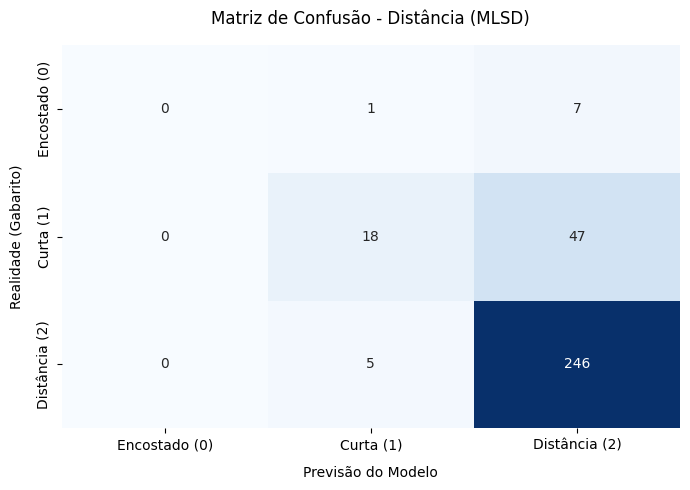

In [6]:
print("📥 Carregando o estado ótimo do modelo para geração de métricas...")
model_mlsd.load_state_dict(torch.load('melhor_modelo_distancia.pth'))
model_mlsd.eval()

y_true = []
y_pred = []
y_prob_both = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model_mlsd(images)

        probabilities = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob_both.extend(probabilities.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob_both = np.array(y_prob_both)

# Binarização necessária para o cálculo do AUC Multiclasse
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

classes = ['Encostado (0)', 'Curta (1)', 'Distância (2)']

cm = confusion_matrix(y_true, y_pred)

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)
support_per_class = cm.sum(axis=1)

acc = accuracy_score(y_true, y_pred)
metrics = {}
averages = ['macro', 'micro', 'weighted']

for avg in averages:
    metrics[f'Prec_{avg}'] = precision_score(y_true, y_pred, average=avg, zero_division=0)
    metrics[f'Rec_{avg}'] = recall_score(y_true, y_pred, average=avg, zero_division=0)
    metrics[f'F1_{avg}'] = f1_score(y_true, y_pred, average=avg, zero_division=0)
    # AUC Multiclasse ovr (One-vs-Rest)
    metrics[f'AUC_{avg}'] = roc_auc_score(y_true_bin, y_prob_both, multi_class='ovr', average=avg)

specificity_per_class = np.divide(TN, (TN + FP), out=np.zeros_like(TN, dtype=float), where=(TN + FP)!=0)

metrics['Spec_macro'] = np.mean(specificity_per_class)
metrics['Spec_micro'] = TN.sum() / (TN.sum() + FP.sum()) if (TN.sum() + FP.sum()) > 0 else 0
metrics['Spec_weighted'] = np.average(specificity_per_class, weights=support_per_class)

# ==========================================
# GERAÇÃO DA TABELA DO ARTIGO (Console)
# ==========================================
print("\n" + "="*145)
print(" TABELA 5 - PERFORMANCE METRICS MLSD (FORMATO CIENTÍFICO)")
print("="*145)

header1 = f"{'Architecture':<14} {'Variant':<10} {'ACC':<7} "
header1 += f"{'Precision':<23} {'Recall':<23} {'F1-Score':<23} {'AUC':<23} {'Specificity':<23}"
print(header1)

header2 = f"{'':<33} "
for _ in range(5):
    header2 += f"{'M':<7} {'m':<7} {'W':<7}   "
print(header2)
print("-" * 145)

row = f"{'TransferKAN':<14} {'MLSD':<10} {acc:<7.3f} "
row += f"{metrics['Prec_macro']:<7.3f} {metrics['Prec_micro']:<7.3f} {metrics['Prec_weighted']:<7.3f}   "
row += f"{metrics['Rec_macro']:<7.3f} {metrics['Rec_micro']:<7.3f} {metrics['Rec_weighted']:<7.3f}   "
row += f"{metrics['F1_macro']:<7.3f} {metrics['F1_micro']:<7.3f} {metrics['F1_weighted']:<7.3f}   "
row += f"{metrics['AUC_macro']:<7.3f} {metrics['AUC_micro']:<7.3f} {metrics['AUC_weighted']:<7.3f}   "
row += f"{metrics['Spec_macro']:<7.3f} {metrics['Spec_micro']:<7.3f} {metrics['Spec_weighted']:<7.3f}"
print(row)
print("="*145 + "\n")

print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=False)
plt.title('Matriz de Confusão - Distância (MLSD)', pad=15)
plt.xlabel('Previsão do Modelo', labelpad=10)
plt.ylabel('Realidade (Gabarito)', labelpad=10)
plt.tight_layout()
plt.show()